# 08 - Final Model

Goal: tune the winning model, define the operational threshold, and export the final metrics that feed the dashboard.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sns.set_style("whitegrid")

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"

train_encoded = pd.read_parquet(f"{PROCESSED_DIR}/train_encoded.parquet")
test_encoded = pd.read_parquet(f"{PROCESSED_DIR}/test_encoded.parquet")
X_train = train_encoded.drop(columns=["churn_flag"])
y_train = train_encoded["churn_flag"]
X_test = test_encoded.drop(columns=["churn_flag"])
y_test = test_encoded["churn_flag"]

with open(f"{MODELS_DIR}/best_model_name.txt") as f:
    BEST_MODEL_NAME = f.read().strip()

print(f"Model to tune: {BEST_MODEL_NAME}")

Model to tune: logistic_regression


## Hyperparameter grid per model

The notebook contains a grid per model type so it works even if the winner chosen in `07_model_evaluation.ipynb` changes.

In [2]:
ESTIMATORS = {
    "logistic_regression": (
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
        {"clf__C": [0.01, 0.1, 1, 10]},
    ),
    "decision_tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [4, 6, 8, 10, None], "min_samples_split": [2, 5, 10]},
    ),
    "random_forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {"n_estimators": [200, 300], "max_depth": [8, 10, 12], "min_samples_split": [2, 5]},
    ),
    "xgboost": (
        XGBClassifier(random_state=42, eval_metric="logloss"),
        {"n_estimators": [200, 300], "max_depth": [3, 5, 7], "learning_rate": [0.05, 0.1]},
    ),
}

base_estimator, param_grid = ESTIMATORS[BEST_MODEL_NAME]

search = GridSearchCV(base_estimator, param_grid, cv=5, scoring="recall", n_jobs=-1)
search.fit(X_train, y_train)

print(f"Best hyperparameters: {search.best_params_}")
print(f"Average recall (cross-validation, train): {search.best_score_:.3f}")

Best hyperparameters: {'clf__C': 0.1}
Average recall (cross-validation, train): 0.663


## Validate on test (once only)

In [3]:
tuned_model = search.best_estimator_
y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"ROC_AUC:   {roc_auc_score(y_test, y_proba):.3f}")

Accuracy:  0.831
Precision: 0.708
Recall:    0.704
F1:        0.706
ROC_AUC:   0.866


## Threshold tuning

The default `0.5` threshold isn't necessarily right for retention. Here the cutoff is adjusted to increase recall without leaving a precision that's useless for commercial action.

In [4]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

MIN_PRECISION = 0.55
valid = precisions[:-1] >= MIN_PRECISION
if valid.any():
    CHOSEN_THRESHOLD = thresholds[valid][recalls[:-1][valid].argmax()]
else:
    CHOSEN_THRESHOLD = 0.5

y_pred_tuned_threshold = (y_proba >= CHOSEN_THRESHOLD).astype(int)
print(f"Chosen threshold: {CHOSEN_THRESHOLD:.3f} (Minimum required precision: {MIN_PRECISION})")
print(f"Recall at this threshold:    {recall_score(y_test, y_pred_tuned_threshold):.3f}")
print(f"Precision at this threshold: {precision_score(y_test, y_pred_tuned_threshold):.3f}")

Chosen threshold: 0.255 (Minimum required precision: 0.55)
Recall at this threshold:    0.824
Precision at this threshold: 0.551


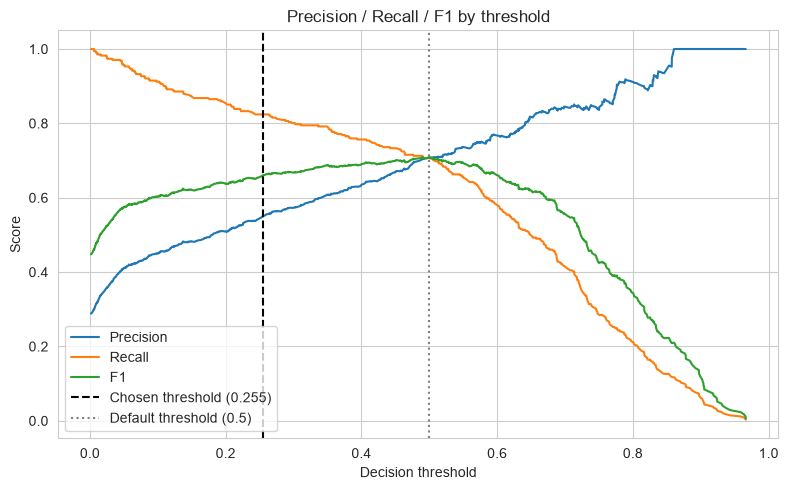

In [5]:
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1")
plt.axvline(CHOSEN_THRESHOLD, color="black", linestyle="--", label=f"Chosen threshold ({CHOSEN_THRESHOLD:.3f})")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by threshold")
plt.legend()
plt.tight_layout()
plt.show()

## Persist metrics of the deployed model

The exported metrics are computed with the chosen operational threshold, not `0.5`.

`ROC_AUC` doesn't depend on the threshold, which is why it's kept as the overall separability metric.

In [6]:
df_final_metrics = pd.DataFrame([{
    "model_name": BEST_MODEL_NAME,
    "threshold": CHOSEN_THRESHOLD,
    "accuracy": accuracy_score(y_test, y_pred_tuned_threshold),
    "precision": precision_score(y_test, y_pred_tuned_threshold),
    "recall": recall_score(y_test, y_pred_tuned_threshold),
    "f1": f1_score(y_test, y_pred_tuned_threshold),
    "roc_auc": roc_auc_score(y_test, y_proba),
}])
df_final_metrics.to_csv(f"{PROCESSED_DIR}/model_final_metrics.csv", index=False)
print("Saved: model_final_metrics.csv")
df_final_metrics

Saved: model_final_metrics.csv


,model_name,threshold,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.254519,0.755499,0.55098,0.824047,0.6604,0.866184


In [7]:
cm = confusion_matrix(y_test, y_pred_tuned_threshold)  # rows=actual [Stayed, Churn], cols=predicted [Stayed, Churn]

df_confusion_matrix = pd.DataFrame(
    [
        {"actual": "Stayed", "predicted": "Stayed", "customers": cm[0, 0]},
        {"actual": "Stayed", "predicted": "Churn", "customers": cm[0, 1]},
        {"actual": "Churn", "predicted": "Stayed", "customers": cm[1, 0]},
        {"actual": "Churn", "predicted": "Churn", "customers": cm[1, 1]},
    ]
)
df_confusion_matrix.to_csv(f"{PROCESSED_DIR}/model_confusion_matrix.csv", index=False)
print("Saved: model_confusion_matrix.csv")
print(f"Total (should be {len(y_test)}): {df_confusion_matrix['customers'].sum()}")
df_confusion_matrix

Saved: model_confusion_matrix.csv
Total (should be 1182): 1182


,actual,predicted,customers
0,Stayed,Stayed,612
1,Stayed,Churn,229
2,Churn,Stayed,60
3,Churn,Churn,281


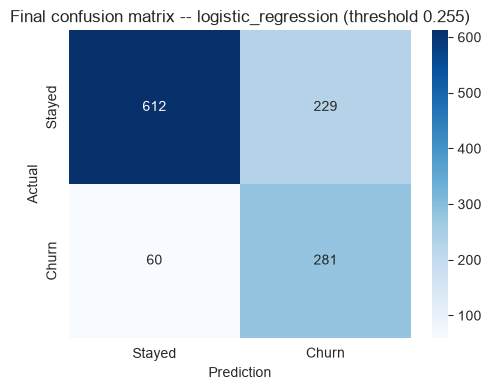

In [8]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Stayed", "Churn"], yticklabels=["Stayed", "Churn"])
plt.title(f"Final confusion matrix -- {BEST_MODEL_NAME} (threshold {CHOSEN_THRESHOLD:.3f})")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

# roc_curve returns one point per unique threshold seen in y_proba (up to len(y_test)+1) --
# it's downsampled to ~200 points to avoid inflating the DirectQuery in Power BI. The
# first and last points (0,0) and (1,1) are always kept so the curve isn't cut off.
MAX_POINTS = 200
if len(fpr) > MAX_POINTS:
    idx = np.linspace(0, len(fpr) - 1, MAX_POINTS, dtype=int)
    idx = np.unique(np.concatenate([[0], idx, [len(fpr) - 1]]))
else:
    idx = np.arange(len(fpr))

df_roc_curve = pd.DataFrame({"fpr": fpr[idx], "tpr": tpr[idx]})
df_roc_curve.to_csv(f"{PROCESSED_DIR}/model_roc_curve.csv", index=False)
print(f"Saved: model_roc_curve.csv ({len(df_roc_curve)} points)")

Saved: model_roc_curve.csv (200 points)


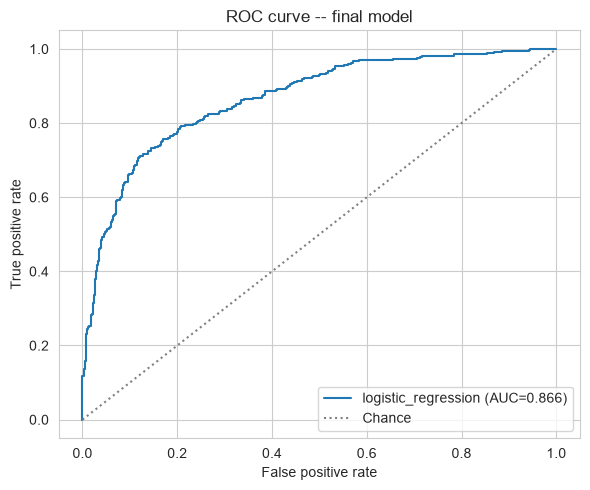

In [10]:
final_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{BEST_MODEL_NAME} (AUC={final_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve -- final model")
plt.legend()
plt.tight_layout()
plt.show()

## Save the final model

In [11]:
joblib.dump(
    {"model": tuned_model, "threshold": CHOSEN_THRESHOLD, "model_name": BEST_MODEL_NAME},
    f"{MODELS_DIR}/final_model.joblib",
)
print(f"Saved: final_model.joblib ({BEST_MODEL_NAME}, threshold={CHOSEN_THRESHOLD:.3f})")

Saved: final_model.joblib (logistic_regression, threshold=0.255)
